In [2]:
pip install pandas numpy matplotlib seaborn openpyxl scikit-learn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
pip install xgboost shap streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 16.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_excel("/content/drive/MyDrive/Telco_customer_churn.xlsx")

In [7]:
df.shape


(7043, 33)

In [8]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [9]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [10]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [11]:
data = df.copy()

In [12]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

data = data.drop(columns=drop_columns)

In [13]:
data["Total Charges"] = pd.to_numeric(
    data["Total Charges"],
    errors="coerce"
)

In [14]:
data["Total Charges"].isnull().sum()

np.int64(11)

In [15]:
data[data["Total Charges"].isnull()][
    ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]
]

,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,0,52.55,NaN,No
2438,0,20.25,NaN,No
2568,0,80.85,NaN,No
2667,0,25.75,NaN,No
2856,0,56.05,NaN,No
4331,0,19.85,NaN,No
4687,0,25.35,NaN,No
5104,0,20.00,NaN,No
5719,0,19.70,NaN,No
6772,0,73.35,NaN,No


In [16]:
data[data["Total Charges"].isnull()]["Tenure Months"]

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [17]:
data["Total Charges"] = data["Total Charges"].fillna(0)

In [18]:
data["Total Charges"].isnull().sum()

np.int64(0)

In [19]:
print("Shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

Shape: (7043, 21)

Missing values:
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

Data types:
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing    

In [20]:
print(data["Churn Label"].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [21]:
print(
    data["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


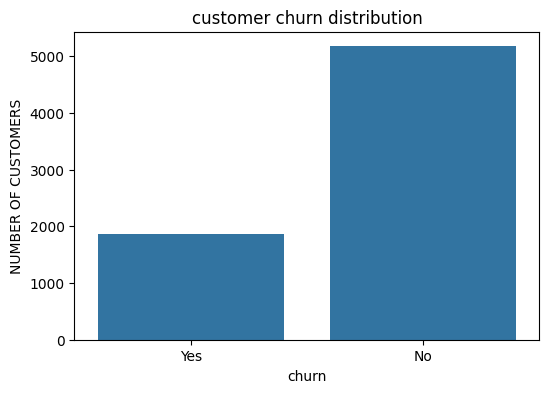

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=data,
    x="Churn Label"
)
plt.title("customer churn distribution")
plt.xlabel("churn")
plt.ylabel("NUMBER OF CUSTOMERS")
plt.show()

In [23]:
data.describe()

,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,4400.295755
std,24.559481,30.090047,2266.794470,1183.057152
min,0.000000,18.250000,0.000000,2003.000000
25%,9.000000,35.500000,398.550000,3469.000000
50%,29.000000,70.350000,1394.550000,4527.000000
75%,55.000000,89.850000,3786.600000,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


In [24]:
data[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [25]:
categorical_columns = data.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n", col)
    print(data[col].value_counts())


 Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

 Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

 Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

 Multiple Lines
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 Internet Service
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 Online Security
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 Online Backup
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

 Device Protection
Device Protection
No                     3095
Yes                

In [26]:
churn_rate = (
    data["Churn Label"]
    .value_counts(normalize=True)["Yes"] * 100
)

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


In [27]:
contract_churn = pd.crosstab(
    data["Contract"],
    data["Churn Label"],
    normalize="index"
) * 100

print(contract_churn)

Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


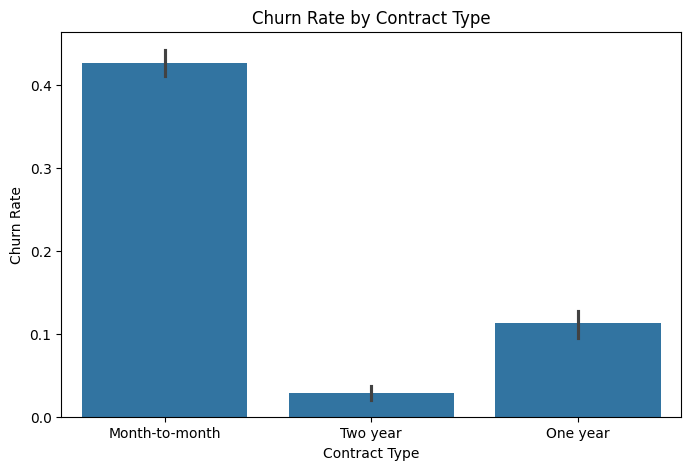

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Contract",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

In [29]:
data["Tenure Group"] = pd.cut(
    data["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [30]:
tenure_churn = pd.crosstab(
    data["Tenure Group"],
    data["Churn Label"],
    normalize="index"
) * 100

print(tenure_churn)

Churn Label          No        Yes
Tenure Group                      
0-12 Months   52.561757  47.438243
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


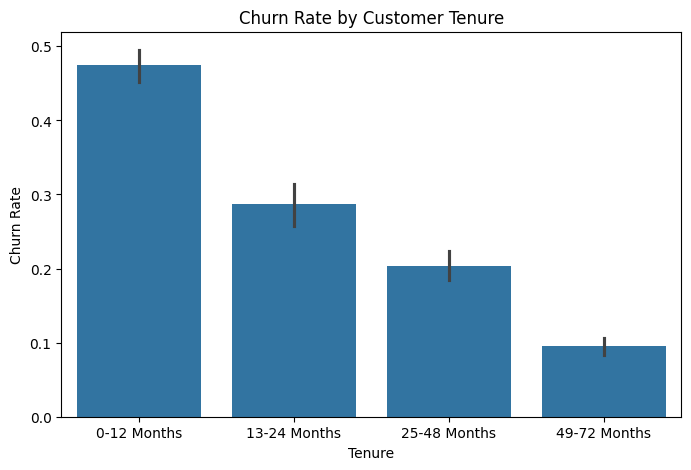

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Tenure Group",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate")

plt.show()

In [32]:
data["Monthly Charge Group"] = pd.cut(
    data["Monthly Charges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [33]:
charge_churn = pd.crosstab(
    data["Monthly Charge Group"],
    data["Churn Label"],
    normalize="index"
) * 100

print(charge_churn)

Churn Label                  No        Yes
Monthly Charge Group                      
Low                   88.356910  11.643090
Medium                76.078915  23.921085
High                  62.178292  37.821708
Very High             71.951220  28.048780


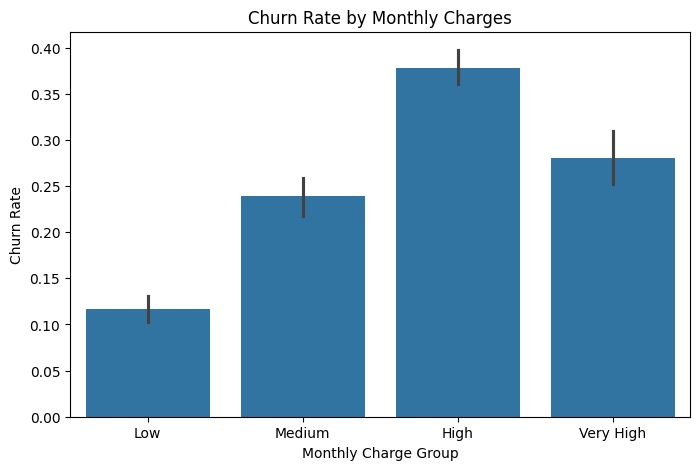

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Monthly Charge Group",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate")

plt.show()

In [35]:
internet_churn = pd.crosstab(
    data["Internet Service"],
    data["Churn Label"],
    normalize="index"
) * 100

print(internet_churn)

Churn Label              No        Yes
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


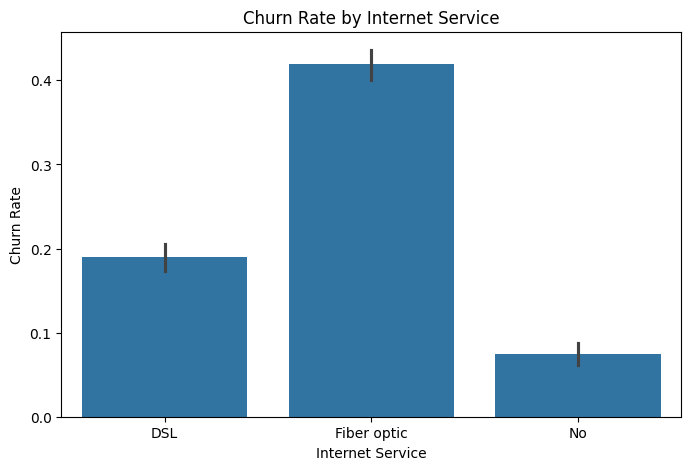

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Internet Service",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.show()

In [37]:
tech_churn = pd.crosstab(
    data["Tech Support"],
    data["Churn Label"],
    normalize="index"
) * 100

print(tech_churn)

Churn Label                 No        Yes
Tech Support                             
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


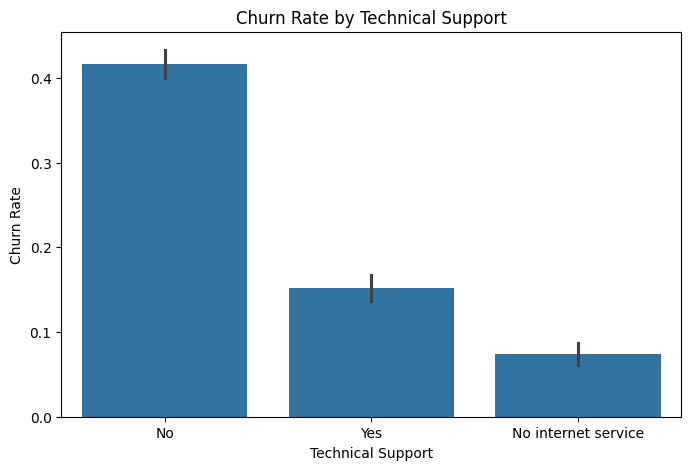

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Tech Support",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate")

plt.show()

In [39]:
payment_churn = pd.crosstab(
    data["Payment Method"],
    data["Churn Label"],
    normalize="index"
) * 100

print(payment_churn)

Churn Label                       No        Yes
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


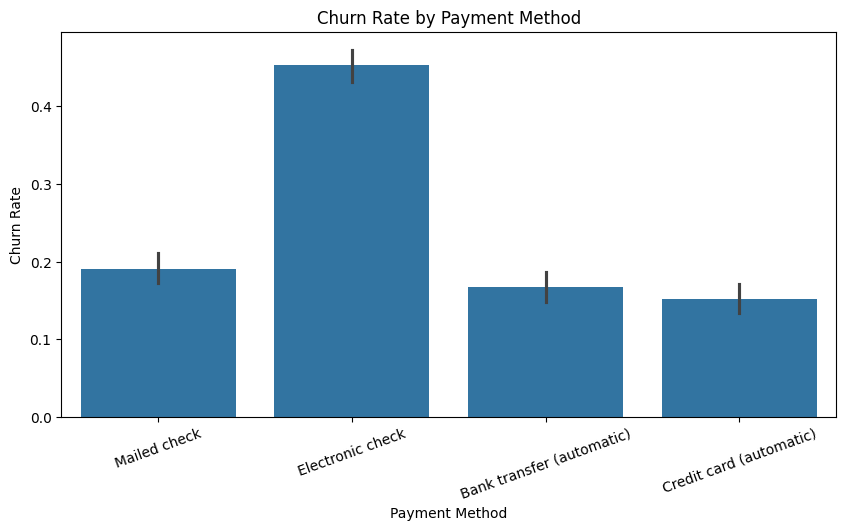

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=data,
    x="Payment Method",
    y=data["Churn Label"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)

plt.show()

In [41]:
security_churn = pd.crosstab(
    data["Online Security"],
    data["Churn Label"],
    normalize="index"
) * 100

print(security_churn)

Churn Label                 No        Yes
Online Security                          
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


In [42]:
billing_churn = pd.crosstab(
    data["Paperless Billing"],
    data["Churn Label"],
    normalize="index"
) * 100

print(billing_churn)

Churn Label               No        Yes
Paperless Billing                      
No                 83.669916  16.330084
Yes                66.434908  33.565092


In [43]:
data.groupby("Churn Label")[
    ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
].mean()

,Tenure Months,Monthly Charges,Total Charges,CLTV
Churn Label,,,,
No,37.569965,61.265124,2549.911442,4490.921337
Yes,17.979133,74.441332,1531.796094,4149.414660


Phase 5 — Feature Engineering & Preparing Data for ML

In [44]:
data = data.drop(
    columns=["Tenure Group", "Monthly Charge Group"],
    errors="ignore"
)

In [45]:
target = "Churn Label"

In [46]:
data["Churn"] = data["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [47]:
data["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [48]:
data = data.drop(columns=["Churn Label"])

In [49]:
data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340,1


In [50]:
data = data.drop(columns=["CLTV"])

In [51]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

In [52]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [53]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numeric_features)

['Tenure Months', 'Monthly Charges', 'Total Charges']


In [54]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_features)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training: (5634, 19)
Testing: (1409, 19)

Training target:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [58]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [59]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

Phase 6 — Model Training


In [61]:
pip install xgboost

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [63]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [64]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [65]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Logistic Regression")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

Logistic Regression
--------------------
Accuracy: 0.8019872249822569
Precision: 0.6435045317220544
Recall: 0.56951871657754
F1 Score: 0.6042553191489362
ROC-AUC: 0.8488671885091322


In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [68]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [69]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [70]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [71]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [72]:
print("Logistic Regression")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

Logistic Regression
--------------------
Accuracy: 0.8019872249822569
Precision: 0.6435045317220544
Recall: 0.56951871657754
F1 Score: 0.6042553191489362
ROC-AUC: 0.8488671885091322


In [73]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [74]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [75]:
random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [76]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

In [77]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [78]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [79]:
print("XGBoost")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_xgb)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_xgb)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_xgb)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb)
)

XGBoost
--------------------
Accuracy: 0.8119233498935415
Precision: 0.6752411575562701
Recall: 0.5614973262032086
F1 Score: 0.6131386861313869
ROC-AUC: 0.8557854762458342


In [84]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8020,0.6435,0.5695,0.6043,0.8489
1,Random Forest,0.7913,0.6299,0.5187,0.5689,0.8335
2,XGBoost,0.8119,0.6752,0.5615,0.6131,0.8558


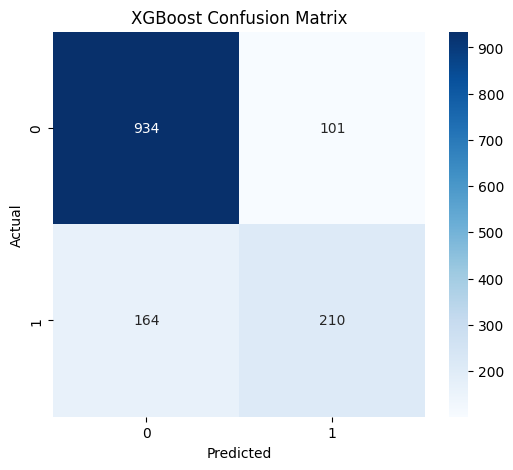

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [97]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8020,0.6435,0.5695,0.6043,0.8489
1,Random Forest,0.7913,0.6299,0.5187,0.5689,0.8335
2,XGBoost,0.8119,0.6752,0.5615,0.6131,0.8558


In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[934 101]
 [164 210]]


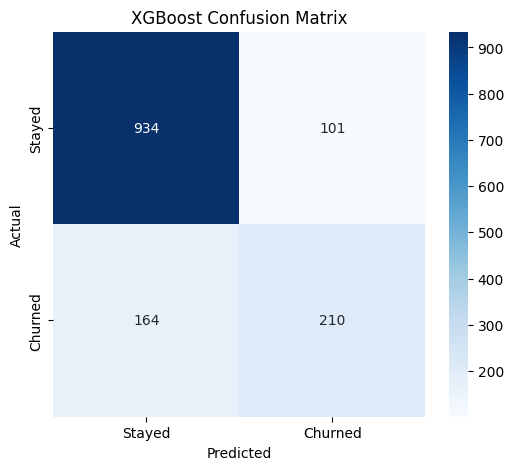

In [87]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [88]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 2.768561872909699


In [89]:
xgb_weighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

In [90]:
xgb_weighted.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [91]:
y_pred_weighted = xgb_weighted.predict(X_test)
y_prob_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

In [92]:
print("Weighted XGBoost")
print("--------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("Precision:", precision_score(y_test, y_pred_weighted))
print("Recall:", recall_score(y_test, y_pred_weighted))
print("F1:", f1_score(y_test, y_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_weighted))

Weighted XGBoost
--------------------
Accuracy: 0.7636621717530163
Precision: 0.5377532228360957
Recall: 0.7807486631016043
F1: 0.6368593238822247
ROC-AUC: 0.8531930558784779


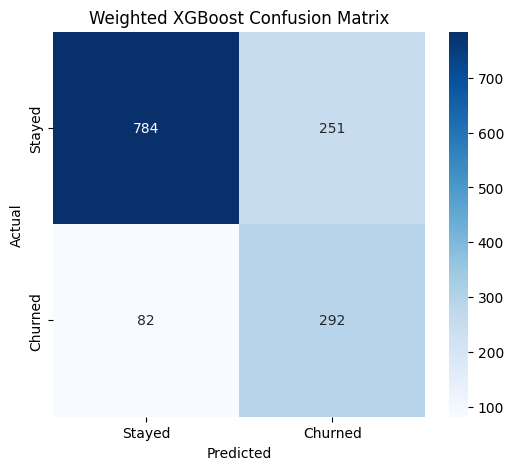

In [93]:
cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted XGBoost Confusion Matrix")

plt.show()

Phase 8 — Threshold Optimization

In [94]:
y_prob_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

In [95]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_weighted >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.422,0.933,0.581
1,0.25,0.446,0.917,0.600
2,0.30,0.467,0.901,0.616
3,0.35,0.484,0.866,0.621
4,0.40,0.498,0.845,0.626
5,0.45,0.515,0.805,0.628
6,0.50,0.538,0.781,0.637
7,0.55,0.552,0.738,0.632
8,0.60,0.577,0.701,0.633
9,0.65,0.600,0.660,0.628


In [98]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (4507, 19)
Validation: (1127, 19)
Test: (1409, 19)


In [99]:
scale_pos_weight = (
    y_train_final.value_counts()[0] /
    y_train_final.value_counts()[1]
)

print(scale_pos_weight)

2.7683946488294313


In [100]:
xgb_final_candidate = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

In [101]:
xgb_final_candidate.fit(
    X_train_final,
    y_train_final
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [102]:
y_val_prob = xgb_final_candidate.predict_proba(X_val)[:, 1]

In [103]:
thresholds = np.arange(0.20, 0.81, 0.05)

validation_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_val_pred
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred
        ),
        "F1": f1_score(
            y_val,
            y_val_pred
        )
    })

validation_df = pd.DataFrame(validation_results)

validation_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.434,0.936,0.593
1,0.25,0.459,0.920,0.612
2,0.30,0.479,0.910,0.627
3,0.35,0.503,0.890,0.643
4,0.40,0.519,0.860,0.647
5,0.45,0.544,0.833,0.658
6,0.50,0.561,0.803,0.660
7,0.55,0.588,0.763,0.664
8,0.60,0.603,0.702,0.649
9,0.65,0.624,0.672,0.647


In [104]:
validation_df[
    validation_df["Recall"] >= 0.70
].sort_values(
    "F1",
    ascending=False
)

,Threshold,Precision,Recall,F1
7,0.55,0.587629,0.762542,0.663755
6,0.50,0.560748,0.802676,0.660248
5,0.45,0.543668,0.832776,0.657860
8,0.60,0.603448,0.702341,0.649150
4,0.40,0.519192,0.859532,0.647355
3,0.35,0.502836,0.889632,0.642512
2,0.30,0.478873,0.909699,0.627451
1,0.25,0.459098,0.919732,0.612472
0,0.20,0.434109,0.936455,0.593220


In [105]:
selected_threshold = 0.60

y_test_prob = (
    xgb_final_candidate.predict_proba(X_test)[:, 1]
)

y_test_final = (
    y_test_prob >= selected_threshold
).astype(int)

In [106]:
print("Final Test Results")
print("------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_test_final)
)

print(
    "Precision:",
    precision_score(y_test, y_test_final)
)

print(
    "Recall:",
    recall_score(y_test, y_test_final)
)

print(
    "F1:",
    f1_score(y_test, y_test_final)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_test_prob)
)

Final Test Results
------------------
Accuracy: 0.7799858055358411
Precision: 0.5720720720720721
Recall: 0.679144385026738
F1: 0.6210268948655256
ROC-AUC: 0.8503255056963496


In [107]:
final_cm = confusion_matrix(
    y_test,
    y_test_final
)

print(final_cm)

[[845 190]
 [120 254]]


In [108]:
import shap

In [109]:
final_xgb = xgb_final_candidate.named_steps["model"]
final_preprocessor = xgb_final_candidate.named_steps["preprocessor"]

X_test_transformed = final_preprocessor.transform(X_test)

feature_names = final_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(final_xgb)

shap_values = explainer.shap_values(X_test_transformed)

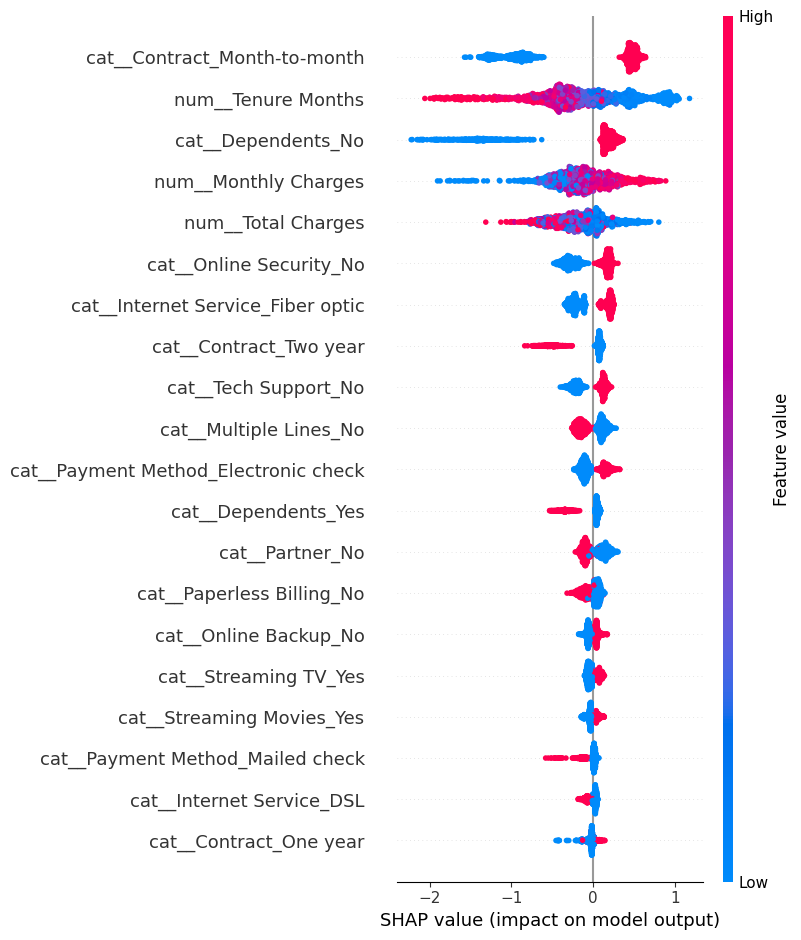

In [110]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [111]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean Absolute SHAP
37,cat__Contract_Month-to-month,0.713526
0,num__Tenure Months,0.501867
9,cat__Dependents_No,0.478486
1,num__Monthly Charges,0.298587
2,num__Total Charges,0.265025
19,cat__Online Security_No,0.227733
17,cat__Internet Service_Fiber optic,0.205883
39,cat__Contract_Two year,0.186174
28,cat__Tech Support_No,0.172125
13,cat__Multiple Lines_No,0.134247


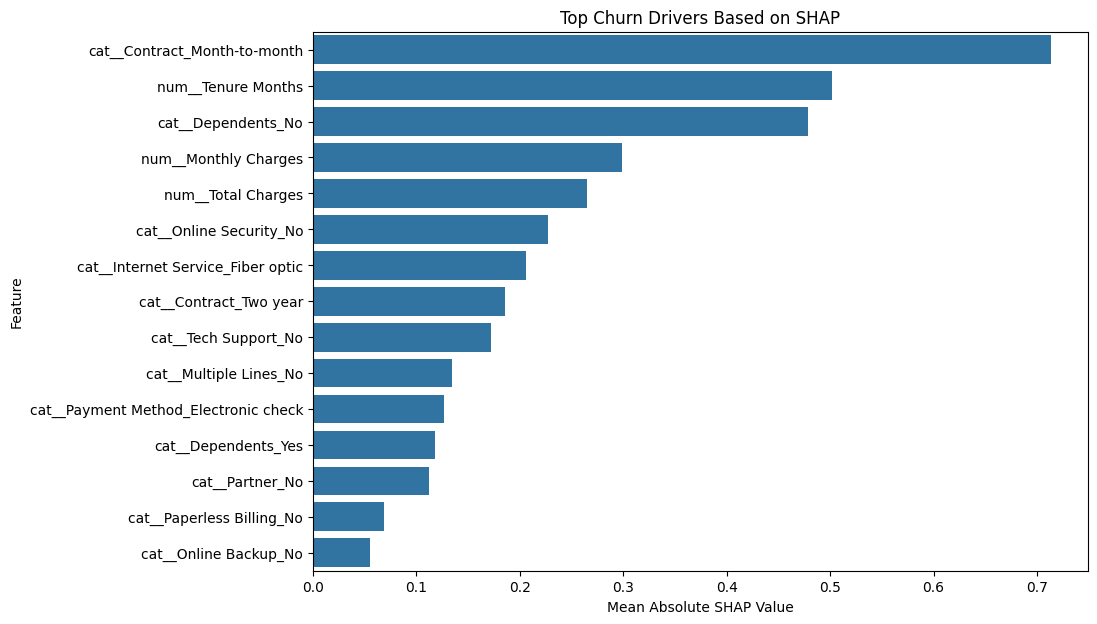

In [112]:
top_shap = shap_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_shap,
    x="Mean Absolute SHAP",
    y="Feature"
)

plt.title("Top Churn Drivers Based on SHAP")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.show()

In [113]:
customer_index = 0

In [114]:
customer = X_test.iloc[customer_index]

print(customer)

Gender                                  Male
Senior Citizen                            No
Partner                                  Yes
Dependents                                No
Tenure Months                             72
Phone Service                            Yes
Multiple Lines                           Yes
Internet Service                 Fiber optic
Online Security                          Yes
Online Backup                            Yes
Device Protection                        Yes
Tech Support                             Yes
Streaming TV                             Yes
Streaming Movies                         Yes
Contract                            Two year
Paperless Billing                        Yes
Payment Method       Credit card (automatic)
Monthly Charges                       114.05
Total Charges                         8468.2
Name: 2196, dtype: object


In [115]:
customer_probability = xgb_final_candidate.predict_proba(
    X_test.iloc[[customer_index]]
)[0, 1]

print(
    f"Churn Probability: {customer_probability:.2%}"
)

Churn Probability: 4.69%


In [116]:
def risk_level(probability):

    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [117]:
risk = risk_level(customer_probability)

print("Risk Level:", risk)

Risk Level: Low


In [118]:
customer_shap = shap_values[customer_index]

In [119]:
customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": customer_shap
})

In [120]:
customer_explanation["Absolute SHAP"] = (
    customer_explanation["SHAP Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "Absolute SHAP",
    ascending=False
)

customer_explanation.head(10)

,Feature,SHAP Value,Absolute SHAP
0,num__Tenure Months,-1.275348,1.275348
37,cat__Contract_Month-to-month,-0.837275,0.837275
39,cat__Contract_Two year,-0.657747,0.657747
38,cat__Contract_One year,-0.441789,0.441789
19,cat__Online Security_No,-0.296790,0.296790
9,cat__Dependents_No,0.277178,0.277178
2,num__Total Charges,-0.235198,0.235198
17,cat__Internet Service_Fiber optic,0.194163,0.194163
28,cat__Tech Support_No,-0.161491,0.161491
44,cat__Payment Method_Electronic check,-0.109471,0.109471


In [121]:
def predict_customer(customer_data):

    probability = xgb_final_candidate.predict_proba(
        customer_data
    )[0, 1]

    risk = risk_level(probability)

    return {
        "Churn Probability": round(probability, 4),
        "Risk Level": risk
    }

In [122]:
result = predict_customer(
    X_test.iloc[[0]]
)

print(result)

{'Churn Probability': np.float32(0.0469), 'Risk Level': 'Low'}


In [123]:
def retention_recommendation(customer):

    recommendations = []

    if customer["Contract"] == "Month-to-month":
        recommendations.append(
            "Offer a discounted long-term contract"
        )

    if customer["Tech Support"] == "No":
        recommendations.append(
            "Offer technical support or a support package"
        )

    if customer["Online Security"] == "No":
        recommendations.append(
            "Offer an online security package"
        )

    if customer["Monthly Charges"] > 80:
        recommendations.append(
            "Review pricing and offer a personalized discount"
        )

    if customer["Tenure Months"] <= 12:
        recommendations.append(
            "Provide a new-customer retention incentive"
        )

    if not recommendations:
        recommendations.append(
            "Continue standard customer engagement"
        )

    return recommendations

In [124]:
customer = X_test.iloc[0]

customer_input = X_test.iloc[[0]]

probability = xgb_final_candidate.predict_proba(
    customer_input
)[0, 1]

risk = risk_level(probability)

recommendations = retention_recommendation(
    customer
)

print("Customer Risk Report")
print("--------------------")

print("Churn Probability:", f"{probability:.2%}")
print("Risk Level:", risk)

print("\nRecommended Actions:")

for recommendation in recommendations:
    print("-", recommendation)

Customer Risk Report
--------------------
Churn Probability: 4.69%
Risk Level: Low

Recommended Actions:
- Review pricing and offer a personalized discount


In [125]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_final_candidate,
    "models/churn_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [126]:
threshold = 0.60

joblib.dump(
    threshold,
    "models/threshold.pkl"
)

['models/threshold.pkl']

In [127]:
dashboard_columns = [
    "CustomerID",
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Churn Label"
]

In [128]:
dashboard_data = df[dashboard_columns].copy()

dashboard_data["Total Charges"] = pd.to_numeric(
    dashboard_data["Total Charges"],
    errors="coerce"
)

dashboard_data["Total Charges"] = (
    dashboard_data["Total Charges"].fillna(0)
)

In [132]:
os.makedirs("data", exist_ok=True)

dashboard_data.to_csv(
    "data/dashboard_customers.csv",
    index=False
)

print("Dashboard data saved.")

Dashboard data saved.


In [131]:
app.py

NameError: name 'app' is not defined

In [134]:
app_content = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Telecom Churn Intelligence",
    page_icon="📊",
    layout="wide"
)

model = joblib.load(
    "models/churn_model.pkl"
)

threshold = joblib.load(
    "models/threshold.pkl"
)

customers = pd.read_csv(
    "data/dashboard_customers.csv"
)

customers["Total Charges"] = pd.to_numeric(
    customers["Total Charges"],
    errors="coerce"
).fillna(0)
'''

with open("app.py", "w") as f:
    f.write(app_content)

print("app.py created successfully!")

app.py created successfully!


To run your Streamlit application, you will need to open a new cell and use the following shell command. Make sure the `app.py` file has been created first.

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-08-16 09:18:03.970 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.245.146:8501

